# Credit Card Fraud — EDA (train split only)

Runs on the EC2 box via SSH tunnel — the kernel, the data, and every save live on the **server**. Commit + push from the server before terminating, or the work dies with it.

**Rules**
- Only `train.csv` is loaded here. The frozen `test.csv` is never read (README → Evaluation protocol).
- Fixed class colors everywhere: **green = fraud (positive), red = legit (negative)** — colorblind-safe shades, validated.

Get the data (on the server):
```
aws s3 cp s3://cc-fraud-381491853558/data/train.csv .
```

## 1. Load & sanity

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
# Fixed class colors: green = fraud (positive), red = legit (negative).
# CVD-safe stand-ins for red/green (validated): bluish-green + vermillion.
C_LEGIT, C_FRAUD = "#D55E00", "#009E73"

df = pd.read_csv("train.csv", dtype="float32")  # float32: cheap habit, halves parse memory
df["Class"] = df["Class"].astype("int8")
print(df.shape)
df["Class"].value_counts()

(227845, 31)


Class
0    227428
1       417
Name: count, dtype: int64

In [2]:
assert df.isna().sum().sum() == 0, "unexpected missing values"
df.describe().T[["mean", "std", "min", "max"]].round(2)

,mean,std,min,max
Time,79042.80,39505.94,0.00,145247.00
V1,-0.07,1.94,-56.41,2.45
V2,-0.01,1.66,-72.72,22.06
V3,0.18,1.49,-33.68,9.38
V4,0.04,1.41,-5.68,16.88
V5,-0.06,1.37,-42.15,34.80
V6,0.03,1.32,-26.16,22.53
V7,-0.03,1.23,-43.56,36.88
V8,0.00,1.21,-73.22,20.01
V9,0.00,1.12,-13.43,15.59


## 2. Traffic & fraud rate over time

The open question from the split: the test period's fraud rate is lower than train's — drift or burstiness? First look at the pattern *inside* train. Two stacked single-axis charts (volume above, rate below), never a dual-axis chart.

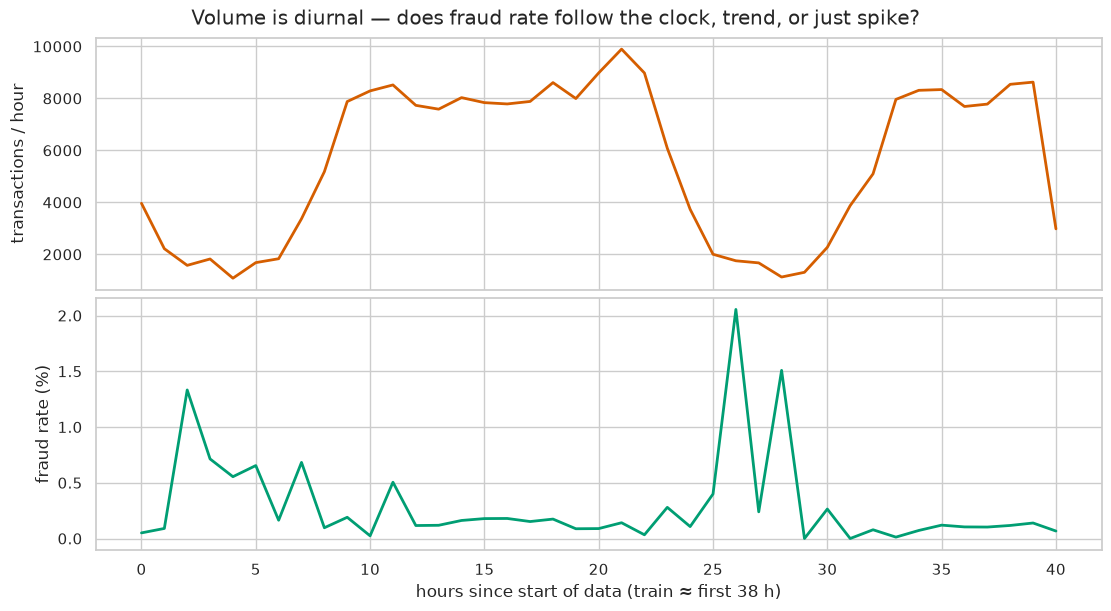

In [3]:
hour = (df["Time"] // 3600).astype(int)
per_hour = df.groupby(hour).agg(txns=("Class", "size"), fraud_rate=("Class", "mean"))

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True, constrained_layout=True)
axes[0].plot(per_hour.index, per_hour["txns"], color=C_LEGIT, lw=2)
axes[0].set_ylabel("transactions / hour")
axes[1].plot(per_hour.index, per_hour["fraud_rate"] * 100, color=C_FRAUD, lw=2)
axes[1].set_ylabel("fraud rate (%)")
axes[1].set_xlabel("hours since start of data (train ≈ first 38 h)")
fig.suptitle("Volume is diurnal — does fraud rate follow the clock, trend, or just spike?")
plt.show()

## 3. Amount

Do frauds differ in transaction size? Raw amounts are so right-skewed the plot is unreadable, so we look at `log1p(Amount)`. Densities per class (each curve's area is 1 — comparing *shapes*, not counts; counts would make the fraud curve invisible at 550:1).

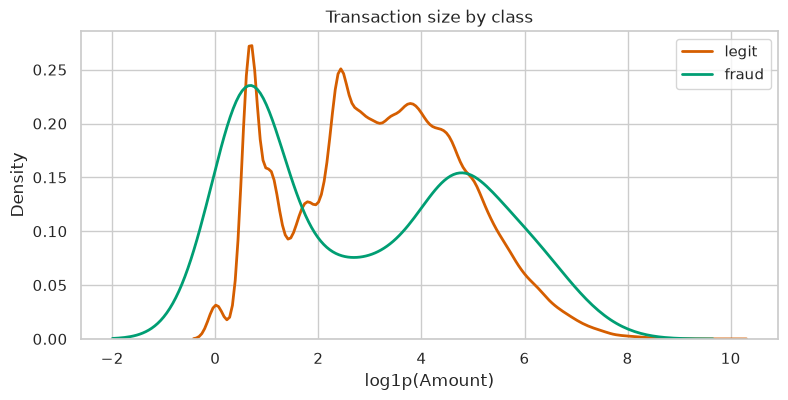

In [4]:
fig, ax = plt.subplots(figsize=(9, 4))
for cls, color, label in [(0, C_LEGIT, "legit"), (1, C_FRAUD, "fraud")]:
    sns.kdeplot(np.log1p(df.loc[df["Class"] == cls, "Amount"]),
                ax=ax, color=color, lw=2, label=label)
ax.set_xlabel("log1p(Amount)")
ax.set_title("Transaction size by class")
ax.legend()
plt.show()

## 4. Which features separate fraud?

Rank every V-feature by **standardized mean difference** — how far apart the fraud and legit means sit, in units of the feature's standard deviation. Then plot the top separators' per-class densities and **read the shapes**:

- fraud curve simply *shifted* → a linear model can use this feature fine;
- fraud as a *second bump*, or extreme in *both* tails → a straight line physically can't score it, and that's evidence for nonlinear models/features (our underfitting diagnosis, made visible).

Caveat: this is univariate — a flashlight, not a map. Features that only matter in combination are invisible here.

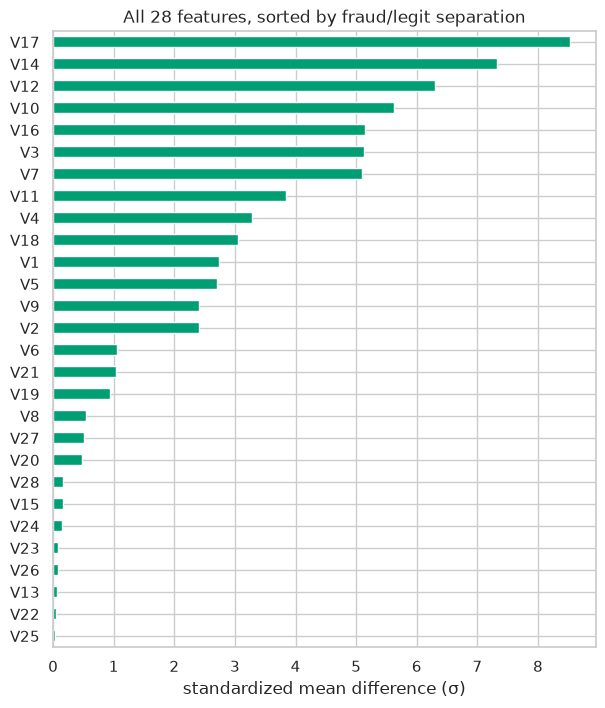

In [5]:
v_feats = [c for c in df.columns if c.startswith("V")]
mu = df.groupby("Class")[v_feats].mean()
sep = ((mu.loc[1] - mu.loc[0]).abs() / df[v_feats].std()).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7, 8))
sep.sort_values().plot.barh(ax=ax, color=C_FRAUD)
ax.set_xlabel("standardized mean difference (σ)")
ax.set_title("All 28 features, sorted by fraud/legit separation")
plt.show()

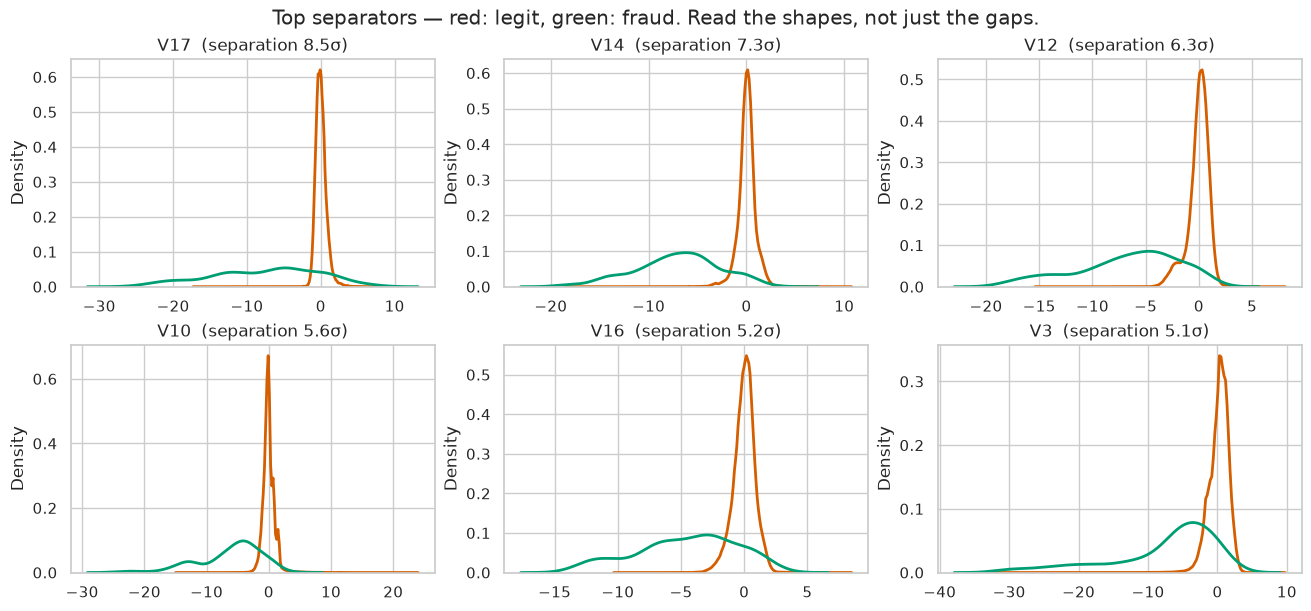

In [6]:
top = sep.index[:6]
fig, axes = plt.subplots(2, 3, figsize=(13, 6), constrained_layout=True)
for f, ax in zip(top, axes.flat):
    for cls, color in [(0, C_LEGIT), (1, C_FRAUD)]:
        sns.kdeplot(df.loc[df["Class"] == cls, f], ax=ax, color=color, lw=2)
    ax.set_title(f"{f}  (separation {sep[f]:.1f}σ)")
    ax.set_xlabel("")
fig.suptitle("Top separators — red: legit, green: fraud. Read the shapes, not just the gaps.")
plt.show()

## 5. Correlations

Teaching point built into this dataset: the V's are PCA components, which are uncorrelated **by construction** — so the heatmap should be near-empty except where `Time` and `Amount` (the two raw features) meet the V's. One cell to confirm, then move on.

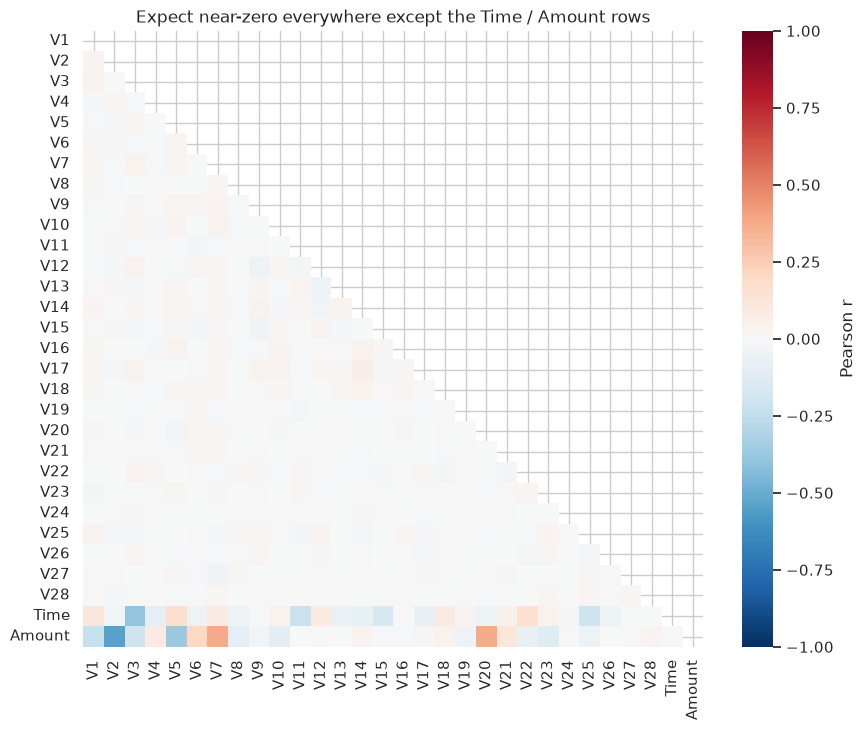

In [7]:
corr = df[v_feats + ["Time", "Amount"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            cbar_kws={"label": "Pearson r"}, ax=ax)
ax.set_title("Expect near-zero everywhere except the Time / Amount rows")
plt.show()

### What the heatmap actually tells us (actionable takeaways)

Checked once, 2026-08-02: V–V orthogonality confirmed — the PCA is as documented. What follows from this plot:

1. **No redundancy to prune.** The V's are mutually uncorrelated, so dropping features to fight collinearity is unnecessary, and logreg coefficients stay stable and individually interpretable.
2. **`log_amount` is partially pre-baked.** Amount correlates with V2 (−), V5 (−), V7 (+), V20 (+), so an explicit amount feature adds *less* than it seems — test its marginal value on validation, don't assume it.
3. **Time features add genuinely new information.** The Time row is near-flat: the V's barely encode when a transaction happened, so the backlog's hour-of-day features (buckets, sin/cos) bring signal the model currently cannot see at all. This *raises* their priority.
4. **Know this map's limits.** It shows linear feature–feature association, not feature–target signal — so it can't propose predictive features by itself (that's section 4's job), and near-zero correlation between two features says nothing about whether their *interaction* is predictive. Use it to budget effort (what's redundant vs. new), not to generate candidates.

## 6. Why PR-AUC (not ROC-AUC) is our headline metric

The class-weighting experiment exposed the trap: the balanced model **improved ROC-AUC while degrading PR-AUC**. Under a ROC headline we'd have kept it; under PR we reject it. Which metric deserves the crown at 550:1 imbalance?

The arithmetic, with our real numbers: the balanced model raises **4,621 false alarms**.

- ROC's x-axis divides them by all 227,428 legit rows → FPR = **2.0%** — a barely visible nudge; the ROC curve still hugs the corner.
- PR's y-axis divides the same 4,621 by the ~5,007 flags raised → precision = **7.7%** — a catastrophe, in plain sight.

Same errors, two denominators. ROC grades against the *ocean of negatives* (which at extreme imbalance forgives almost any number of false alarms); PR grades against *your own alarms* (what a fraud team actually experiences). That's why PR-AUC is the standard headline for rare-event problems.

The plot below shows both views of both models, with the threshold-0.5 operating points marked as dots.

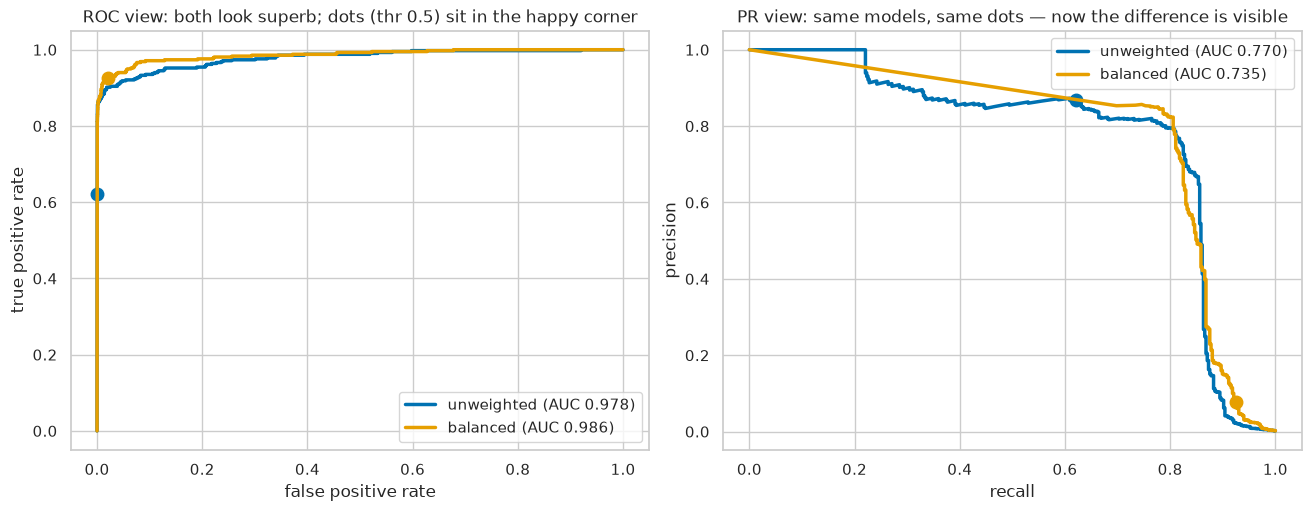

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             roc_auc_score, average_precision_score)

X, y = df.drop(columns=["Class"]), df["Class"]
Xs = StandardScaler().fit_transform(X)

C_BASE, C_BAL = "#0072B2", "#E69F00"  # model colors (validated pair)
models = {
    "unweighted": (LogisticRegression(max_iter=1000), C_BASE),
    "balanced":   (LogisticRegression(max_iter=1000, class_weight="balanced"), C_BAL),
}

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
for name, (m, color) in models.items():
    p = m.fit(Xs, y).predict_proba(Xs)[:, 1]
    fpr, tpr, _ = roc_curve(y, p)
    ax_roc.plot(fpr, tpr, color=color, lw=2.5,
                label=f"{name} (AUC {roc_auc_score(y, p):.3f})")
    prec, rec, _ = precision_recall_curve(y, p)
    ax_pr.plot(rec, prec, color=color, lw=2.5,
               label=f"{name} (AUC {average_precision_score(y, p):.3f})")
    # mark the threshold-0.5 operating point on both views
    pred = p >= 0.5
    tp = int(((pred == 1) & (y == 1)).sum()); fp = int(((pred == 1) & (y == 0)).sum())
    fn = int(((pred == 0) & (y == 1)).sum()); tn = int(((pred == 0) & (y == 0)).sum())
    ax_roc.plot(fp / (fp + tn), tp / (tp + fn), "o", color=color, ms=9)
    ax_pr.plot(tp / (tp + fn), tp / max(tp + fp, 1), "o", color=color, ms=9)

ax_roc.set(xlabel="false positive rate", ylabel="true positive rate",
           title="ROC view: both look superb; dots (thr 0.5) sit in the happy corner")
ax_pr.set(xlabel="recall", ylabel="precision",
          title="PR view: same models, same dots — now the difference is visible")
ax_roc.legend(loc="lower right"); ax_pr.legend(loc="upper right")
plt.show()

### Calibration: the reliability diagram

A model is **calibrated** when its probabilities mean what they say — among transactions it scores "1%", about 1 in 100 is actually fraud. The reliability diagram tests exactly that: sort predictions into 10 quantile bins, and for each bin plot *average predicted probability* (x) against *observed fraud rate* (y). Honest probabilities land on the diagonal; points **above** it = the model underpredicts (reality is worse than it claims); **below** = overpredicts. Log-log axes because our probabilities span several orders of magnitude.

Predictions to check: the unweighted model should track the diagonal reasonably (logistic regression trained on true frequencies tends to be roughly calibrated); the balanced model should sit **far below** the diagonal — weighting taught it to cry wolf, so its "50%" is really ~1%. This is the picture behind its terrible normalized entropy, and the reason weighted models need recalibration before anything downstream consumes their probabilities.

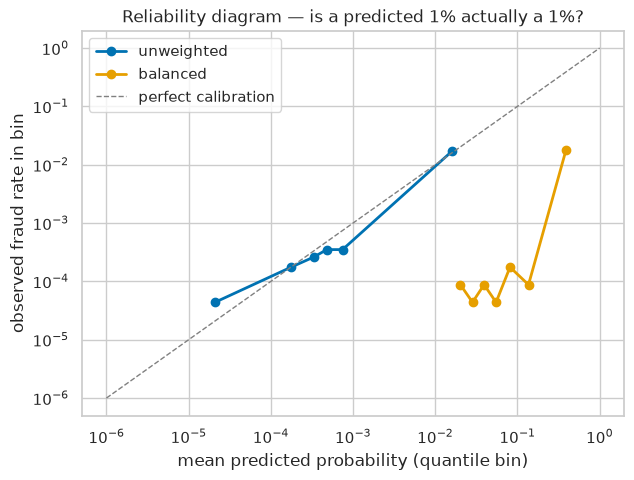

In [9]:
from sklearn.calibration import calibration_curve

fig, ax = plt.subplots(figsize=(7, 5))
for name, (m, color) in models.items():          # models were fit in the cell above
    p = m.predict_proba(Xs)[:, 1]
    frac_pos, mean_pred = calibration_curve(y, p, n_bins=10, strategy="quantile")
    keep = frac_pos > 0                          # log scale can't show empty bins
    ax.plot(mean_pred[keep], frac_pos[keep], "o-", color=color, lw=2, label=name)
ax.plot([1e-6, 1], [1e-6, 1], "--", color="gray", lw=1, label="perfect calibration")
ax.set(xscale="log", yscale="log",
       xlabel="mean predicted probability (quantile bin)",
       ylabel="observed fraud rate in bin",
       title="Reliability diagram — is a predicted 1% actually a 1%?")
ax.legend()
plt.show()

## 7. Verdict protocol

Everything above produces *hypotheses*, not conclusions. Any feature idea born here is judged by **train-eval PR-AUC** in a training run (no validation set — scope decision; train metrics measure fit, so big winners stay provisional) — never by eyeballing these plots, and never against the frozen test set, which is touched exactly once at final model comparison.

## 8. Error analysis — who escapes the champion?

The champion (`logreg-gen2-l2`, PR-AUC 0.842) still misses ~98 of 417 training frauds at threshold 0.5. This section studies those escapees: are they *near-misses* (scored almost-suspicious) or *invisibles* (scored like ordinary traffic)? And what do they have in common? The answers decide where the next improvement comes from — threshold, features, or capacity.

Fetch the champion artifact first (on the server, from the repo folder):
```
aws s3 cp s3://cc-fraud-381491853558/results/models/logreg-gen2-l2/model.joblib champion.joblib
```

In [ ]:
import subprocess
from pathlib import Path

import joblib

if not Path("champion.joblib").exists():   # self-fetch so headless runs need no manual step
    subprocess.run(["aws", "s3", "cp",
                    "s3://cc-fraud-381491853558/results/models/logreg-gen2-l2/model.joblib",
                    "champion.joblib"], check=True)

champ = joblib.load("champion.joblib")   # needs features.py importable (repo root — it is)
proba_all = champ.predict_proba(df.drop(columns=["Class"]))[:, 1]

fraud_mask = df["Class"] == 1
caught = fraud_mask & (proba_all >= 0.5)
missed = fraud_mask & (proba_all < 0.5)
print(f"frauds: {int(fraud_mask.sum())}  caught: {int(caught.sum())}  missed: {int(missed.sum())}")

C_CAUGHT, C_MISSED = "#0072B2", "#E69F00"  # validated pair; NOT the class colors — both groups are fraud
fig, ax = plt.subplots(figsize=(10, 4))
bins = np.linspace(-6, 0, 48)
ax.hist(np.log10(proba_all[caught]), bins=bins, color=C_CAUGHT, alpha=0.75,
        label=f"caught ({int(caught.sum())})")
ax.hist(np.log10(proba_all[missed]), bins=bins, color=C_MISSED, alpha=0.75,
        label=f"missed ({int(missed.sum())})")
ax.axvline(np.log10(0.5), color="gray", ls="--", lw=1.5, label="threshold 0.5")
ax.set(xlabel="log10(predicted fraud probability)", ylabel="frauds",
       title="The fork: are missed frauds near-misses or invisibles?")
ax.legend()
plt.show()

In [11]:
# Medians per group: does "missed" look like "legit" (invisible) or like
# "caught" (borderline)? Plus each group's typical score.
key = ["Amount", "V17", "V14", "V12", "V10", "V16", "V3"]
comp = pd.DataFrame({
    f"caught ({int(caught.sum())})": df.loc[caught, key].median(),
    f"missed ({int(missed.sum())})": df.loc[missed, key].median(),
    "legit": df.loc[~fraud_mask, key].median(),
}).round(2)
print("median predicted probability:  caught",
      f"{np.median(proba_all[caught]):.3f}   missed {np.median(proba_all[missed]):.4f}")
comp

median predicted probability:  caught 0.988   missed 0.0084


,caught (319),missed (98),legit
Amount,12.31,15.01,23.42
V17,-9.33,0.55,-0.04
V14,-7.83,-1.63,0.07
V12,-7.22,-0.75,0.12
V10,-6.07,-0.82,-0.09
V16,-5.45,0.11,0.06
V3,-6.09,-0.69,0.37


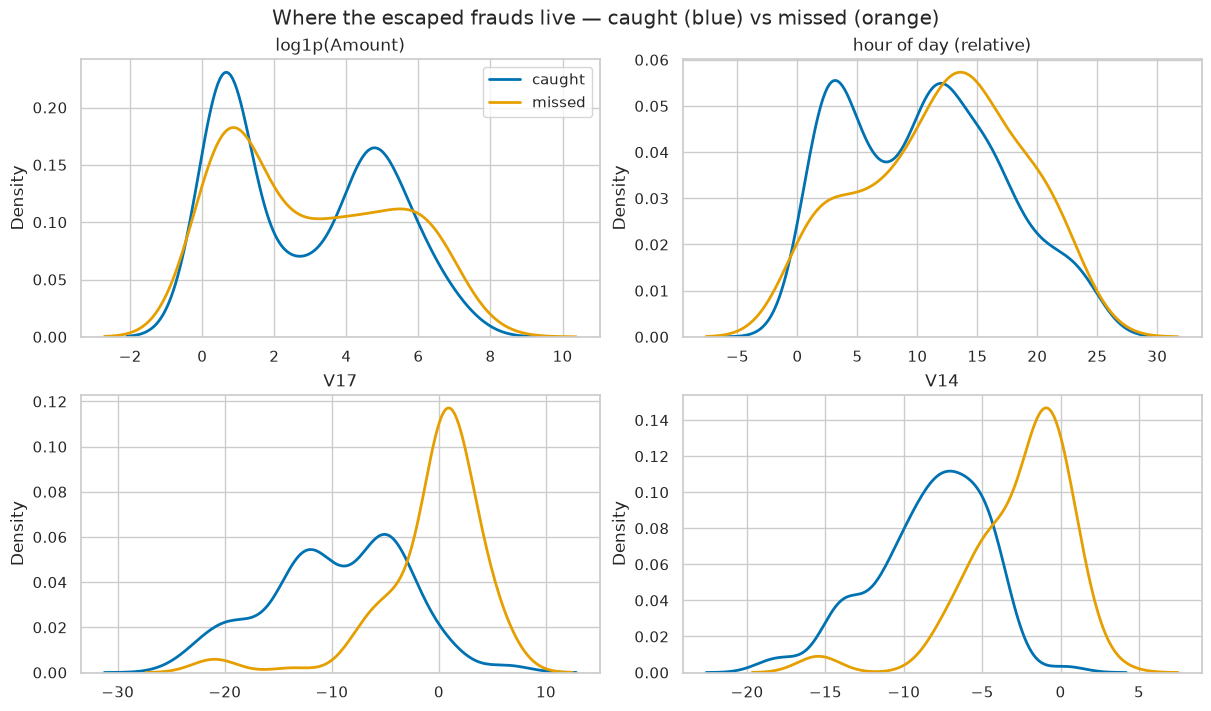

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
panels = [
    ("log1p(Amount)", np.log1p(df["Amount"])),
    ("hour of day (relative)", (df["Time"] / 3600) % 24),
    ("V17", df["V17"]),
    ("V14", df["V14"]),
]
for (label, series), ax in zip(panels, axes.flat):
    sns.kdeplot(series[caught], ax=ax, color=C_CAUGHT, lw=2, label="caught")
    sns.kdeplot(series[missed], ax=ax, color=C_MISSED, lw=2, label="missed")
    ax.set_title(label)
    ax.set_xlabel("")
axes.flat[0].legend()
fig.suptitle("Where the escaped frauds live — caught (blue) vs missed (orange)")
plt.show()

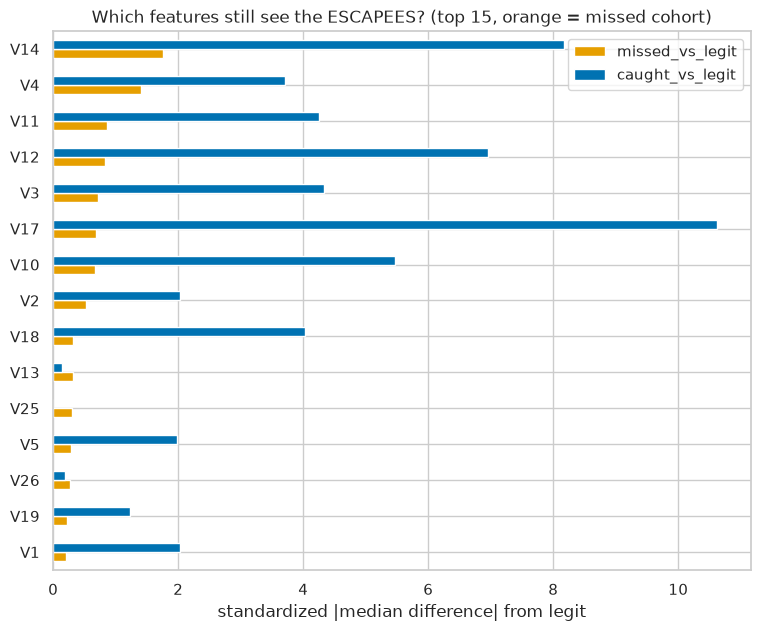

,missed_vs_legit,caught_vs_legit
V14,1.76,8.18
V4,1.40,3.71
V11,0.85,4.25
V12,0.82,6.95
V3,0.71,4.34
V17,0.68,10.63
V10,0.66,5.46
V2,0.53,2.02


In [13]:
# The audit: for EVERY feature, how far do the MISSED frauds sit from legit
# traffic? (standardized median difference — medians because n=98 is small).
# If some mid-ranked V still separates the escapees, it's feature material;
# if nothing does, the camouflage is total and only new data helps.
legit_df = df[~fraud_mask]
audit = {}
for f in [c for c in df.columns if c.startswith("V")] + ["Amount"]:
    scale = df[f].std()
    audit[f] = {
        "missed_vs_legit": abs(df.loc[missed, f].median() - legit_df[f].median()) / scale,
        "caught_vs_legit": abs(df.loc[caught, f].median() - legit_df[f].median()) / scale,
    }
audit = pd.DataFrame(audit).T.sort_values("missed_vs_legit", ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
audit.head(15)[::-1].plot.barh(ax=ax, color=[C_MISSED, C_CAUGHT])
ax.set_xlabel("standardized |median difference| from legit")
ax.set_title("Which features still see the ESCAPEES? (top 15, orange = missed cohort)")
plt.show()
audit.head(8).round(2)

### How to read section 8

- **The probability histogram is the fork in the road.** If missed frauds cluster just left of the threshold line, they're *near-misses* — threshold tuning harvests them cheaply. If they pile up at 10⁻³ and below, they're *invisible* to this model — no threshold reaches them; only new features or more capacity (XGBoost) will.
- **The caught-vs-missed comparisons name the blind spot.** Wherever the orange (missed) distribution separates from the blue (caught) one — an amount range, a time of day, a V-region — that's a candidate feature or a capacity argument, stated by the data itself.
- Findings here are hypotheses for the next training run, judged per the verdict protocol above — never acted on by eyeball alone.